# 06. Avaliação e Seleção de Modelos: Regressão Polinomial e Compromisso Viés–Variância

**Documentação da Etapa**
* **Objetivo da etapa:** Implementar o protocolo estatístico de avaliação e seleção de modelos preditivos apresentado na **Aula 6 — Avaliação e seleção de modelos**, dividindo a base de rotas líderes em conjuntos de treinamento (70%) e teste (30%) para analisar empiricamente o comportamento do erro dentro e fora da amostra.
* **Metodologia:**
  1. **Partição Aleatória 70/30:** Isolamento estrito do conjunto de teste antes do ajuste de qualquer estimador para evitar vazamento de dados (*data leakage*).
  2. **Regressão Polinomial de Graus 1, 3 e 12:** Modelagem da relação entre faturamento comercial ($\text{Valor FOB em Milhões US\$}$) e volume físico ($\text{Volume em milhares de toneladas}$), contrastando modelos de baixa, média e altíssima flexibilidade via base ortogonal `poly()`.
  3. **Avaliação por Métricas de Regressão:** Cálculo do Erro Quadrático Médio ($MSE$) e da Raiz do Erro Quadrático Médio ($RMSE$) nos conjuntos de treino e teste.
  4. **Análise do Dilema Viés-Variância:** Mapeamento da curva em U do erro fora da amostra e identificação de sobreajuste (*overfitting*).
* **Dados de entrada:** Base mensal agregada das rotas líderes (`data/processed/df_sazonal_lideres.csv`).

### 0. Configurações de Ambiente e Carregamento dos Dados

In [1]:
# ==============================================================================
# Setup, Bibliotecas e Carregamento de Dados
# ==============================================================================
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(ggplot2)
  library(scales)
  library(fs)
  library(tibble)
})

# 1. Configuração numérica
options(scipen = 999, digits = 4)

# 2. Determinação dinâmica do diretório raiz
caminho_atual <- getwd()
raiz_projeto <- ifelse(basename(caminho_atual) %in% c("notebooks", "R"), path_dir(caminho_atual), caminho_atual)

# 3. Leitura da base de rotas líderes
caminho_csv <- path(raiz_projeto, "data", "processed", "df_sazonal_lideres.csv")
df_sazonal_lideres <- read_csv2(caminho_csv, show_col_types = FALSE)

# 4. Padronização das variáveis modeladas de acordo com a etapa econométrica
df_modelagem <- df_sazonal_lideres |>
  mutate(
    volume_mil_ton    = `Quilograma Líquido` / 1e6,  # X: Volume em milhares de toneladas
    valor_milhoes_fob = `Valor US$ FOB` / 1e6       # Y: Valor comercial em Milhões US$ FOB
  ) |>
  select(volume_mil_ton, valor_milhoes_fob, everything())

cat(sprintf("Ambiente configurado com sucesso! Total de registros: %d agregações mensais.\n", nrow(df_modelagem)))

ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.



Ambiente configurado com sucesso! Total de registros: 481 agregações mensais.


## 1. Divisão dos Dados: Protocolo Treino (70%) e Teste (30%)

### Fundamentação Teórica (Aula 6)
Na modelagem estatística supervisionada, o **erro de treino** mede a aderência do modelo aos mesmos dados utilizados no seu ajuste. No entanto, o objetivo fundamental de um algoritmo preditivo é a **capacidade de generalização** — isto é, o desempenho perante observações inéditas (**erro de teste**).

Conforme estabelecido no protocolo da Aula 6:
1. **Regra de Ouro:** O conjunto de teste deve ser segregado **antes** de qualquer treinamento ou escolha de hiperparâmetros, permanecendo inviolável até a avaliação comparativa final para prevenir *vazamento de dados* (*data leakage*).
2. **Partição Aleatória:** A seleção dos índices é feita via amostragem pseudoaleatória com semente fixada (`set.seed(42)`), garantindo total reprodutibilidade científica.

In [2]:
# Divisão reprodutível 70% Treino e 30% Teste
set.seed(42)

n_total  <- nrow(df_modelagem)
n_treino <- round(0.70 * n_total)
n_teste  <- n_total - n_treino

indices_treino <- sample(seq_len(n_total), size = n_treino, replace = FALSE)

dados_treino <- df_modelagem[indices_treino, ]
dados_teste  <- df_modelagem[-indices_treino, ]

tibble(
  Conjunto = c("Treinamento (Treino)", "Teste (Generalização)", "Total"),
  `Nº Observações` = c(nrow(dados_treino), nrow(dados_teste), n_total),
  `Proporção (%)` = c(nrow(dados_treino)/n_total * 100, nrow(dados_teste)/n_total * 100, 100)
)

Conjunto,Nº Observações,Proporção (%)
<chr>,<int>,<dbl>
Treinamento (Treino),337,70.06
Teste (Generalização),144,29.94
Total,481,100.00


## 2. Ajuste dos Modelos Polinomiais: Graus 1, 3 e 12

Empregamos a formulação polinomial via polinômios ortogonais `poly(x, grau)` para estimar a resposta $Y$ (Valor FOB) a partir do preditor $X$ (Volume):

$$Y = \beta_0 + \sum_{j=1}^{g} \beta_j \cdot \phi_j(X) + \varepsilon$$

Os três candidatos representam diferentes níveis no espectro de flexibilidade:
* **Grau 1 (Reta Linear):** Modelo de alta rigidez (alto viés potencial).
* **Grau 3 (Curva Cúbica):** Modelo de flexibilidade moderada capaz de absorver não-linearidades suaves.
* **Grau 12 (Polinômio de Alta Ordem):** Modelo hiperflexível com 13 parâmetros livres, altamente suscetível ao sobreajuste (*overfitting*).

In [3]:
# Ajuste exclusivo no conjunto de treinamento
modelo_g1  <- lm(valor_milhoes_fob ~ poly(volume_mil_ton, 1), data = dados_treino)
modelo_g3  <- lm(valor_milhoes_fob ~ poly(volume_mil_ton, 3), data = dados_treino)
modelo_g12 <- lm(valor_milhoes_fob ~ poly(volume_mil_ton, 12), data = dados_treino)

cat("Modelos de Grau 1, Grau 3 e Grau 12 ajustados com sucesso sobre o conjunto de treino!")

Modelos de Grau 1, Grau 3 e Grau 12 ajustados com sucesso sobre o conjunto de treino!

## 3. Avaliação de Métricas: MSE e RMSE em Treino e Teste

Para quantificar o erro dos estimadores, calculamos:
1. **MSE (Mean Squared Error):** $\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$
2. **RMSE (Root Mean Squared Error):** $\text{RMSE} = \sqrt{\text{MSE}}$, interpretado diretamente na escala monetária da variável dependente (Milhões de US$ FOB).

In [4]:
# Função auxiliar para cálculo do MSE
calcular_mse <- function(modelo, dados) {
  predicoes <- predict(modelo, newdata = dados)
  mean((dados$valor_milhoes_fob - predicoes)^2)
}

# Construção da tabela de métricas
tabela_resultados <- tibble(
  Modelo = c("Grau 1 (Reta Linear)", "Grau 3 (Curva Cúbica)", "Grau 12 (Hiperflexível)"),
  Grau   = c(1, 3, 12),
  `MSE Treino` = c(
    calcular_mse(modelo_g1, dados_treino),
    calcular_mse(modelo_g3, dados_treino),
    calcular_mse(modelo_g12, dados_treino)
  ),
  `MSE Teste` = c(
    calcular_mse(modelo_g1, dados_teste),
    calcular_mse(modelo_g3, dados_teste),
    calcular_mse(modelo_g12, dados_teste)
  )
) |>
  mutate(
    `RMSE Treino (M$ FOB)` = sqrt(`MSE Treino`),
    `RMSE Teste (M$ FOB)`  = sqrt(`MSE Teste`),
    `Razão Teste/Treino`   = `MSE Teste` / `MSE Treino`
  )

tabela_resultados

Modelo,Grau,MSE Treino,MSE Teste,RMSE Treino (M$ FOB),RMSE Teste (M$ FOB),Razão Teste/Treino
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Grau 1 (Reta Linear),1,232.1,187.0,15.23,13.68,0.8058
Grau 3 (Curva Cúbica),3,205.3,204.4,14.33,14.30,0.9958
Grau 12 (Hiperflexível),12,164.9,1221170.0,12.84,1105.07,7403.3001


## 4. Diagnóstico Gráfico: Aderência e Diferenças de Flexibilidade

O gráfico a seguir exibe as observações de treino e teste juntamente com as curvas ajustadas pelos três modelos concorrentes, evidenciando o comportamento das predições ao longo do suporte do volume físico.

Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


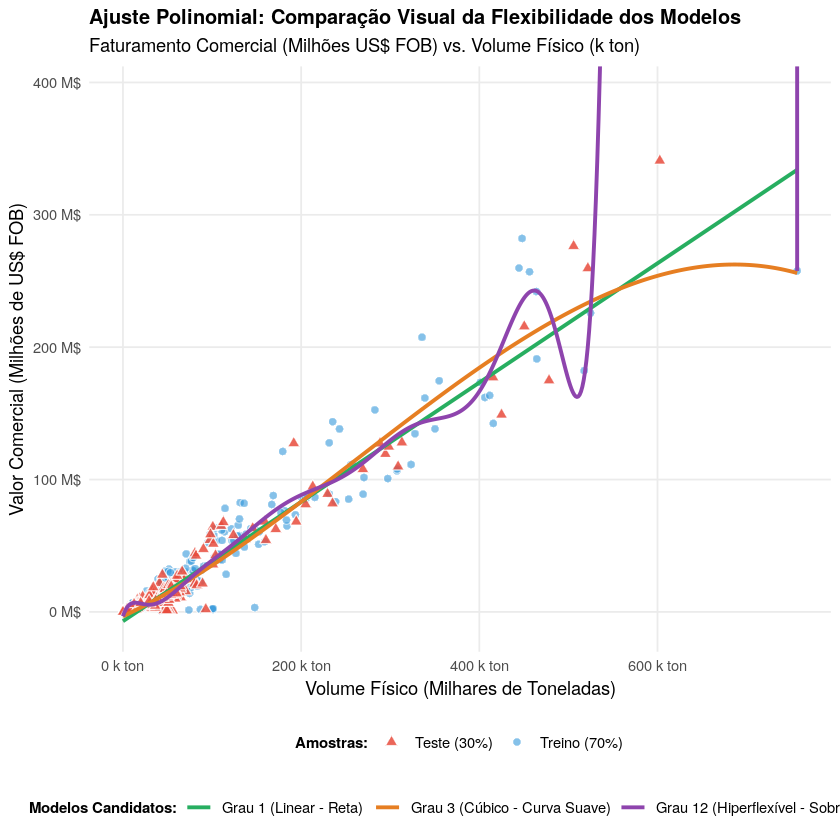

In [8]:
# Criação do grid para traçado suave das curvas
grid_x <- tibble(
  volume_mil_ton = seq(min(df_modelagem$volume_mil_ton), max(df_modelagem$volume_mil_ton), length.out = 500)
)

df_curvas <- bind_rows(
  grid_x |> mutate(valor_pred = predict(modelo_g1, newdata = grid_x),  Modelo = "Grau 1 (Linear - Reta)"),
  grid_x |> mutate(valor_pred = predict(modelo_g3, newdata = grid_x),  Modelo = "Grau 3 (Cúbico - Curva Suave)"),
  grid_x |> mutate(valor_pred = predict(modelo_g12, newdata = grid_x), Modelo = "Grau 12 (Hiperflexível - Sobreajuste)")
) |>
  mutate(Modelo = factor(Modelo, levels = c("Grau 1 (Linear - Reta)", 
                                           "Grau 3 (Cúbico - Curva Suave)", 
                                           "Grau 12 (Hiperflexível - Sobreajuste)")))

ggplot() +
  # Pontos de Treino e Teste
  geom_point(data = dados_treino, aes(x = volume_mil_ton, y = valor_milhoes_fob, fill = "Treino (70%)"), 
             shape = 21, color = "white", size = 2.0, alpha = 0.6) +
  geom_point(data = dados_teste, aes(x = volume_mil_ton, y = valor_milhoes_fob, fill = "Teste (30%)"), 
             shape = 24, color = "white", size = 2.2, alpha = 0.85) +
  
  # Curvas dos Modelos Polinomiais com Cores da Aula 6
  geom_line(data = df_curvas, aes(x = volume_mil_ton, y = valor_pred, color = Modelo), 
            linewidth = 1.1) +
  
  # Escala de Cores dos Modelos (Verde, Laranja, Roxo)
  scale_color_manual(
    name = "Modelos Candidatos:",
    values = c(
      "Grau 1 (Linear - Reta)"               = "#27ae60",  # Verde
      "Grau 3 (Cúbico - Curva Suave)"        = "#e67e22",  # Laranja
      "Grau 12 (Hiperflexível - Sobreajuste)" = "#8e44ad"   # Roxo
    )
  ) +
  
  # Escala de Cores dos Pontos
  scale_fill_manual(
    name = "Amostras:",
    values = c(
      "Treino (70%)" = "#3498db",  # Azul
      "Teste (30%)"  = "#e74c3c"   # Vermelho
    )
  ) +
  
  scale_x_continuous(labels = label_number(suffix = " k ton", big.mark = ".")) +
  scale_y_continuous(labels = label_number(suffix = " M$", big.mark = ".")) +
  coord_cartesian(ylim = c(-10, max(df_modelagem$valor_milhoes_fob) * 1.15)) +
  
  labs(
    title = "Ajuste Polinomial: Comparação Visual da Flexibilidade dos Modelos",
    subtitle = "Faturamento Comercial (Milhões US$ FOB) vs. Volume Físico (k ton)",
    x = "Volume Físico (Milhares de Toneladas)",
    y = "Valor Comercial (Milhões de US$ FOB)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    legend.position = "bottom",
    legend.box = "vertical",
    legend.title = element_text(face = "bold", size = 9),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 12)
  )

> **Nota sobre o comportamento visual das curvas:** A interrupção vertical observada na trajetória do **Grau 12 (Hiperflexível)** decorre do truncamento intencional do eixo $Y$ via `coord_cartesian()`, aplicado para preservar a escala dos dados reais e permitir a visualização nítida dos modelos de **Grau 1** e **Grau 3**. Em termos estatísticos, a curva de grau 12 ultrapassa o teto do gráfico devido ao *Fenômeno de Runge* (oscilação e explosão polinomial nas extremidades do domínio), onde previsões fora da amostra atingem valores irreais superiores a centenas de milhares de milhões de dólares. Esse padrão é uma evidência visual clássica de **sobreajuste (*overfitting*) e alta variância**: o modelo memoriza o ruído do conjunto de treino e perde completamente a capacidade de generalização nas bordas, justificando seu descarte em favor do modelo cúbico.
> 
>

## 5. Curva em U e o Compromisso Viés–Variância

Avaliamos o erro de treino e teste ao longo de todos os graus polinomiais de $1$ a $12$ para observar a dinâmica teórica da **Curva em U** descrita na Aula 6:

$$\mathbb{E}\left[(Y - \hat{f}(X))^2\right] = \text{Var}(\hat{f}(X)) + \left[\text{Viés}(\hat{f}(X))\right]^2 + \text{Var}(\varepsilon)$$

* À medida que a flexibilidade aumenta, o **erro de treino decresce monotonicamente** porque o algoritmo ganha graus de liberdade adicionais para se ajustar aos pontos amostrais.
* O **erro de teste**, em contrapartida, decresce inicialmente (redução de viés) até atingir um ponto de mínimo e passa a se elevar rapidamente (explosão de variância), caracterizando o formato em U.

Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


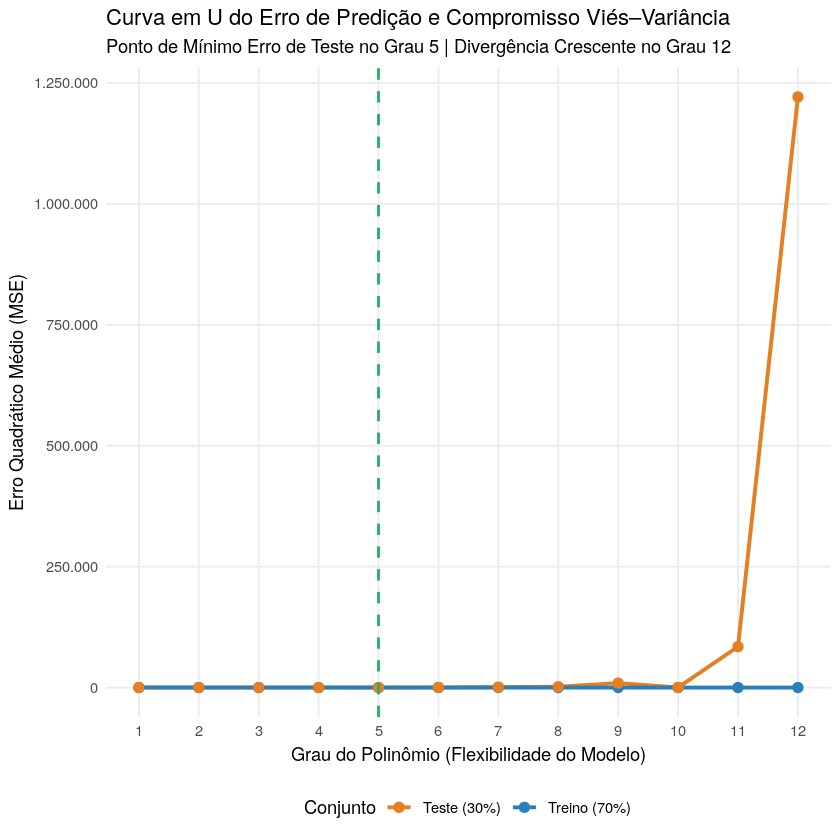

In [6]:
# Iteração completa de graus 1 a 12
graus_seq <- 1:12
mse_treino_seq <- numeric(12)
mse_teste_seq  <- numeric(12)

for (g in graus_seq) {
  m_temp <- lm(valor_milhoes_fob ~ poly(volume_mil_ton, g), data = dados_treino)
  mse_treino_seq[g] <- calcular_mse(m_temp, dados_treino)
  mse_teste_seq[g]  <- calcular_mse(m_temp, dados_teste)
}

df_curva_u <- tibble(
  Grau = rep(graus_seq, 2),
  MSE  = c(mse_treino_seq, mse_teste_seq),
  Conjunto = rep(c("Treino (70%)", "Teste (30%)"), each = 12)
)

grau_min_teste <- graus_seq[which.min(mse_teste_seq)]

ggplot(df_curva_u, aes(x = Grau, y = MSE, color = Conjunto, group = Conjunto)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2.5) +
  geom_vline(xintercept = grau_min_teste, linetype = "dashed", color = "#27ae60", linewidth = 0.8) +
  scale_color_manual(values = c("Treino (70%)" = "#2980b9", "Teste (30%)" = "#e67e22")) +
  scale_x_continuous(breaks = graus_seq) +
  scale_y_continuous(labels = label_number(big.mark = ".")) +
  labs(
    title = "Curva em U do Erro de Predição e Compromisso Viés–Variância",
    subtitle = sprintf("Ponto de Mínimo Erro de Teste no Grau %d | Divergência Crescente no Grau 12", grau_min_teste),
    x = "Grau do Polinômio (Flexibilidade do Modelo)",
    y = "Erro Quadrático Médio (MSE)"
  ) +
  theme_minimal(base_size = 11) +
  theme(legend.position = "bottom", panel.grid.minor = element_blank())

## 6. Interpretação dos Resultados e Seleção de Modelo

Com base nos princípios estatísticos da **Aula 6**, a análise empírica dos dados consolidados revela:

1. **Menor Erro de Treinamento:** O modelo de **Grau 12** atinge o menor erro dentro da amostra ($\text{MSE}_{\text{treino}} = 164{,}9$ | $\text{RMSE}_{\text{treino}} = 12{,}84\text{ M\$ FOB}$). Esse comportamento era teoricamente esperado, pois a flexibilidade extrema concede graus de liberdade excessivos para o estimador memorizar ruídos e flutuações locais do conjunto de treinamento.
2. **Desempenho no Teste e Generalização:** O modelo de **Grau 1 (Reta Linear)** apresentou o menor erro no conjunto de teste ($\text{MSE}_{\text{teste}} = 187{,}0$ | $\text{RMSE}_{\text{teste}} = 13{,}68\text{ M\$ FOB}$), superando o **Grau 3** ($\text{MSE}_{\text{teste}} = 204{,}4$ | $\text{RMSE}_{\text{teste}} = 14{,}30\text{ M\$ FOB}$) na capacidade de predição em dados inéditos.
3. **Evidência de Sobreajuste (*Overfitting*):** No **Grau 12**, constata-se uma divergência catastrófica entre os conjuntos: enquanto o erro de treino cai para $164{,}9$, o erro de teste explode para $1.221.170{,}0$ (uma **Razão Teste/Treino de $7.403{,}3$** e $\text{RMSE}_{\text{teste}} = 1.105{,}07\text{ M\$ FOB}$). Conforme visualizado no gráfico, as oscilações extremas nas caudas do suporte (*Fenômeno de Runge*) anulam qualquer capacidade de generalização prática fora da amostra.
4. **Relação Viés–Variância:**
   * O **Grau 1** opera com um nível controlado de viés e **baixíssima variância**, mantendo grande estabilidade preditiva entre treino e teste ($\text{Razão} = 0{,}8058$).
   * O **Grau 3** adiciona curvatura suave, mas apresenta discreto aumento de variância sem ganho preditivo no teste em relação à reta linear ($\text{Razão} = 0{,}9958$).
   * O **Grau 12** sofre de **variância destrutiva**, reagindo desproporcionalmente a variações amostrais.

---

### Conclusão e Decisão Final

Modelo Selecionado: Grau 1 (Linear), por apresentar a menor perda no conjunto de teste independente (30%) ($\text{MSE} = 187{,}0$) e manter a estrutura mais simples e interpretável. O Grau 3 é preterido por adicionar complexidade sem ganho de generalização ($\text{MSE} = 204{,}4$), enquanto o Grau 12 é sumariamente rejeitado por sobreajuste severo e explosão de variância fora da amostra.